# Notebook 05 - Full Pipeline & Report

**This is the main notebook.** It runs all 3 quality checks on every image
and produces a full `quality_report.csv` with PASS/FAIL per image.

## Pipeline Summary

```
Image
 ├── 1. Blur Check    → Laplacian variance < 100 = FAIL
 ├── 2. Glare Check   → HSV V-ratio > 10%   = FAIL
 └── 3. Framing Check → Aspect 1.3–2.0      = PASS
         ↓
   All 3 PASS → Overall = PASS ✅
   Any FAIL   → Overall = FAIL ❌
```

**Output:** `outputs/quality_report.csv`

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from src.pipeline import run_pipeline, save_report, print_summary

## 1. Run Full Pipeline

In [2]:
# Run all quality checks on all images
# This may take 1-2 minutes for 480 images
results = run_pipeline()
print_summary(results)


🔍 Found 480 images in 'C:\kyc-document-quality\uk_password'
─────────────────────────────────────────────────────────────────


Processing:   0%|          | 1/480 [00:00<05:10,  1.54img/s]

  ❌ P_UK_427583910_L1_B1_A1_D1.jpg                | Blur:   458.0 | Glare:0.031 | Aspect:1.23 | FAIL


Processing:   0%|          | 2/480 [00:01<04:44,  1.68img/s]

  ❌ P_UK_427583910_L1_B1_A1_D2.jpg                | Blur:   629.3 | Glare:0.042 | Aspect:1.07 | FAIL


...

  ✅ P_UK_748392615_L4_B4_A2_D2.jpg                | Blur:   478.8 | Glare:0.003 | Aspect:1.85 | PASS


Processing: 100%|█████████▉| 479/480 [03:45<00:00,  2.24img/s]

  ✅ P_UK_748392615_L4_B4_A3_D1.jpg                | Blur:   355.6 | Glare:0.008 | Aspect:1.48 | PASS


Processing: 100%|██████████| 480/480 [03:45<00:00,  2.12img/s]

  ✅ P_UK_748392615_L4_B4_A3_D2.jpg                | Blur:   283.7 | Glare:0.001 | Aspect:1.56 | PASS

📊  QUALITY REPORT SUMMARY
  Total images   : 480
  ✅ PASS        : 100  (20%)
  ❌ FAIL        : 380  (79%)
──────────────────────────────────────────────────
  🌀 Blurry      : 0
  ☀️  Glare       : 0
  📐 Bad framing : 380


## 2. Save CSV Report

In [3]:
save_report(results)

# Load into pandas for analysis
df = pd.DataFrame(results)
print(f'\nDataFrame shape: {df.shape}')
df.head()


📄 Report saved → outputs\quality_report.csv

DataFrame shape: (480, 17)


,filename,path,person_id,lighting,background,angle,distance,blur_score,is_blurry,blur_label,glare_ratio,has_glare,glare_label,aspect_ratio,good_framing,framing_label,overall
0,P_UK_427583910_L1_B1_A1_D1.jpg,C:\kyc-document-quality\uk_password\UK\4275839...,427583910,L1,B1,A1,D1,457.97,False,Sharp,0.0309,False,No Glare,1.231,False,Too Narrow / Portrait,FAIL
1,P_UK_427583910_L1_B1_A1_D2.jpg,C:\kyc-document-quality\uk_password\UK\4275839...,427583910,L1,B1,A1,D2,629.29,False,Sharp,0.0422,False,No Glare,1.070,False,Too Narrow / Portrait,FAIL
2,P_UK_427583910_L1_B1_A2_D1.jpg,C:\kyc-document-quality\uk_password\UK\4275839...,427583910,L1,B1,A2,D1,368.96,False,Sharp,0.0359,False,No Glare,0.519,False,Too Narrow / Portrait,FAIL
3,P_UK_427583910_L1_B1_A2_D2.jpg,C:\kyc-document-quality\uk_password\UK\4275839...,427583910,L1,B1,A2,D2,388.63,False,Sharp,0.0344,False,No Glare,0.717,False,Too Narrow / Portrait,FAIL
4,P_UK_427583910_L1_B1_A3_D1.jpg,C:\kyc-document-quality\uk_password\UK\4275839...,427583910,L1,B1,A3,D1,270.53,False,Sharp,0.0077,False,No Glare,0.650,False,Too Narrow / Portrait,FAIL


## 3. Overall PASS / FAIL Chart

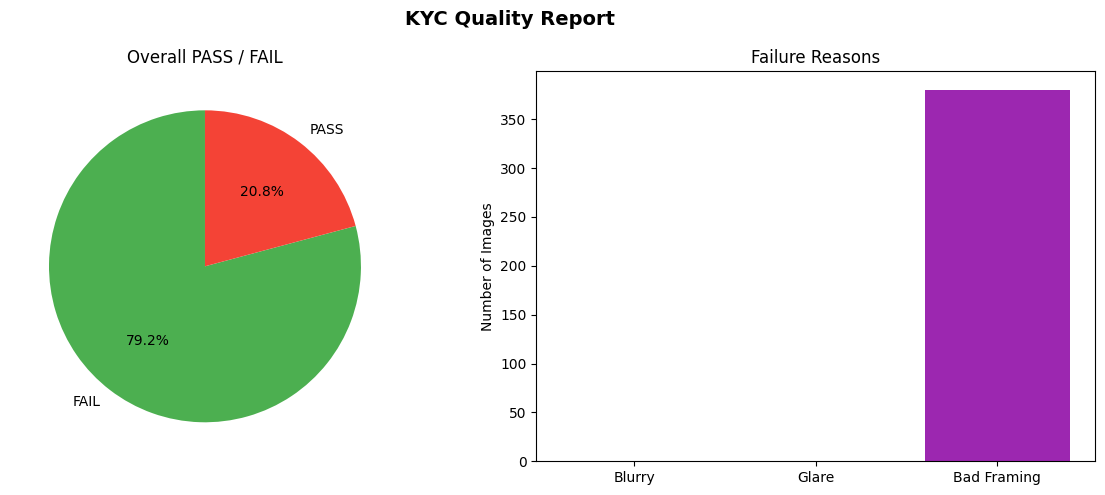

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
counts = df['overall'].value_counts()
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'], startangle=90)
axes[0].set_title('Overall PASS / FAIL')

# Bar chart — failure reasons
failure_counts = {
    'Blurry':      df['is_blurry'].sum(),
    'Glare':       df['has_glare'].sum(),
    'Bad Framing': (~df['good_framing']).sum(),
}
axes[1].bar(failure_counts.keys(), failure_counts.values(),
            color=['#2196F3', '#FF9800', '#9C27B0'])
axes[1].set_title('Failure Reasons')
axes[1].set_ylabel('Number of Images')

plt.suptitle('KYC Quality Report', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. PASS Rate by Lighting Condition

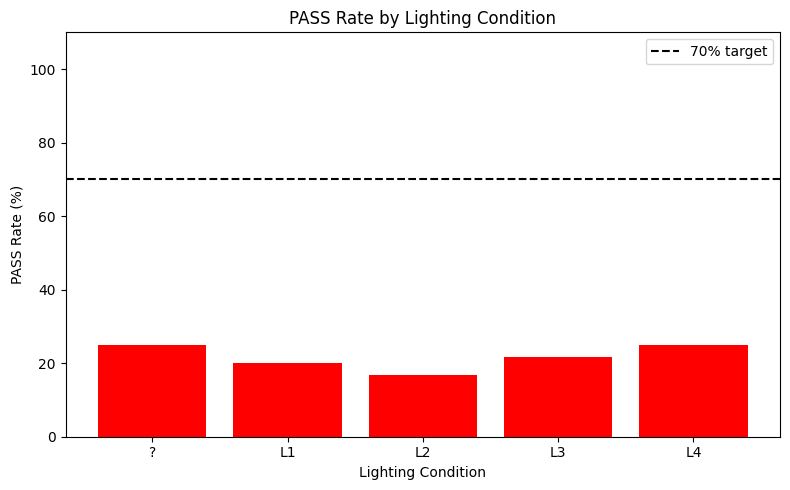

In [5]:
pass_by_lighting = df.groupby('lighting')['overall'].apply(
    lambda x: (x == 'PASS').sum() / len(x) * 100
).reset_index()
pass_by_lighting.columns = ['lighting', 'pass_rate']

plt.figure(figsize=(8, 5))
plt.bar(pass_by_lighting['lighting'], pass_by_lighting['pass_rate'],
        color=['green' if r >= 70 else 'red' for r in pass_by_lighting['pass_rate']])
plt.axhline(70, color='black', linestyle='--', label='70% target')
plt.xlabel('Lighting Condition')
plt.ylabel('PASS Rate (%)')
plt.title('PASS Rate by Lighting Condition')
plt.ylim(0, 110)
plt.legend()
plt.tight_layout()
plt.show()

## 5. Full Results Table

In [6]:
# Show summary stats per person
summary = df.groupby('person_id').agg(
    total   = ('overall', 'count'),
    passed  = ('overall', lambda x: (x == 'PASS').sum()),
    blurry  = ('is_blurry', 'sum'),
    glare   = ('has_glare', 'sum'),
).reset_index()
summary['pass_rate'] = (summary['passed'] / summary['total'] * 100).round(1)
summary

,person_id,total,passed,blurry,glare,pass_rate
0,427583910,96,19,0,0,19.8
1,487239561,96,31,0,0,32.3
2,489153026,92,15,0,0,16.3
3,489352716,96,15,0,0,15.6
4,748392615,96,19,0,0,19.8
5,unknown,4,1,0,0,25.0


In [7]:
print('\n Pipeline complete!')
print('Open outputs/quality_report.csv for the full results.')


 Pipeline complete!
Open outputs/quality_report.csv for the full results.
